# Car Price Prediction — Data Cleaning & Feature Engineering

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Handle Missing / Invalid Values

In [3]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df_clean = df.drop_duplicates().reset_index(drop=True)
print('After dedupe:', df_clean.shape)

Missing values: 0
Duplicates: 2
After dedupe: (299, 9)


## 3. Imputation

In [4]:
df_imputed = df_clean.copy()
print('NaN count:', df_imputed.isnull().sum().sum())

NaN count: 0


## 4. Distribution Comparison Before vs After Imputation

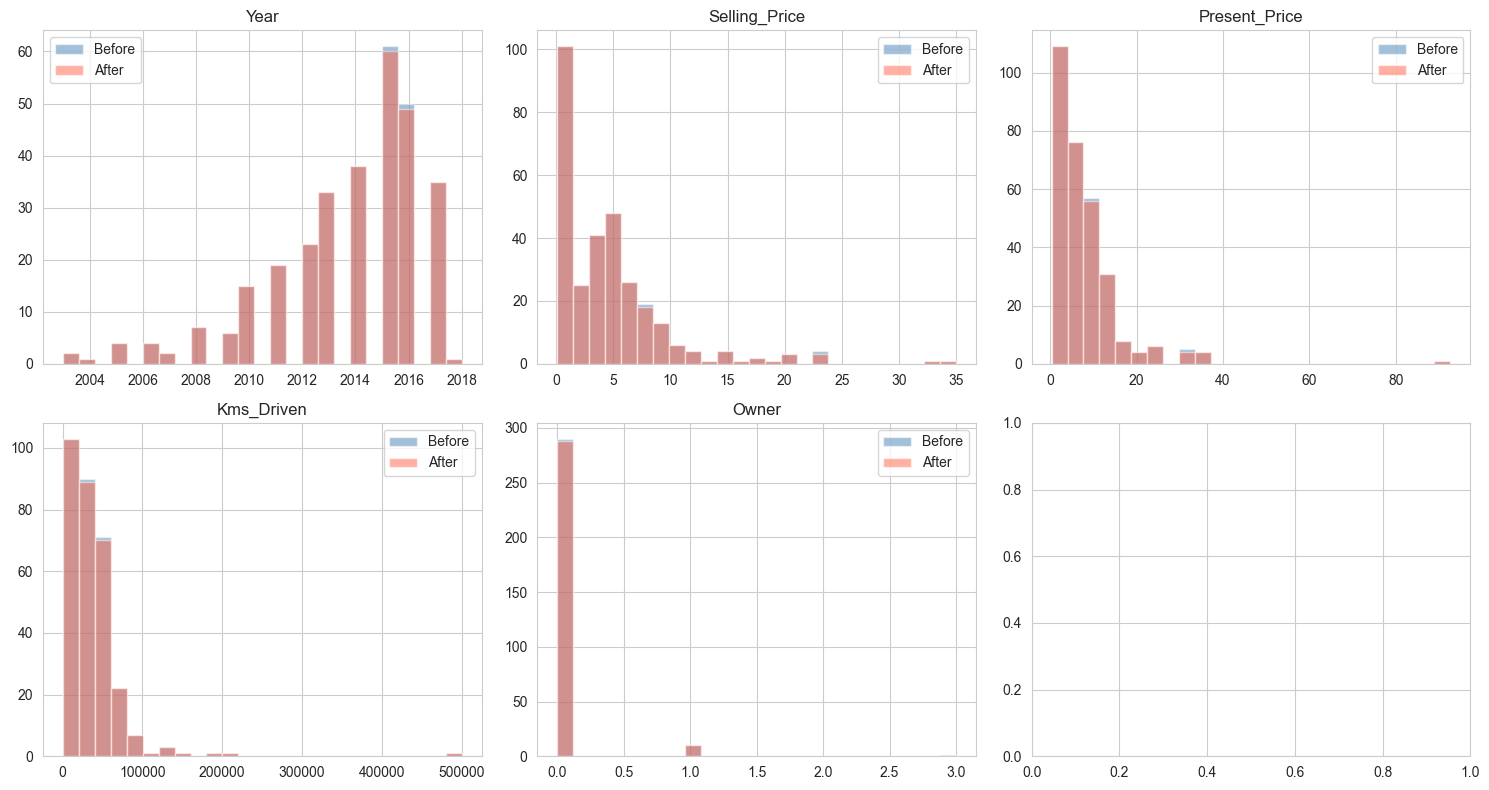

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (299, 9)


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Kms_per_Year
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,6,4500.000000
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,7,6142.857143
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,3,2300.000000
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,9,577.777778
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,6,7075.000000


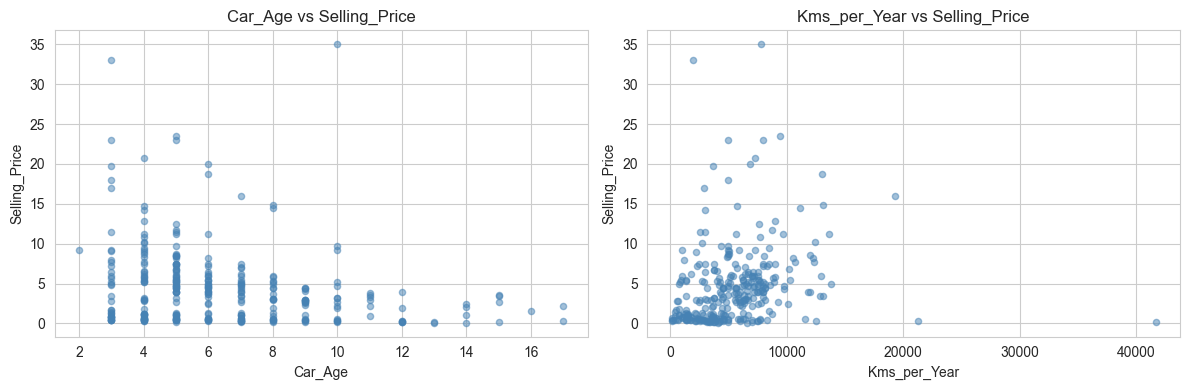

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if 'Car_Age' in df_feat.columns:
    axes[0].scatter(df_feat['Car_Age'], df_feat['Selling_Price'], alpha=0.5, s=20, color='steelblue')
    axes[0].set_xlabel('Car_Age'); axes[0].set_ylabel('Selling_Price')
    axes[0].set_title('Car_Age vs Selling_Price')
if 'Kms_per_Year' in df_feat.columns:
    axes[1].scatter(df_feat['Kms_per_Year'], df_feat['Selling_Price'], alpha=0.5, s=20, color='steelblue')
    axes[1].set_xlabel('Kms_per_Year'); axes[1].set_ylabel('Selling_Price')
    axes[1].set_title('Kms_per_Year vs Selling_Price')
plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Final shape:', df_encoded.shape)

Categorical columns: ['Fuel_Type', 'Seller_Type', 'Transmission']
Final shape: (299, 10)


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/car_data_cleaned.csv', index=False)
print('Saved -> data/car_data_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (299, 10)
Saved -> data/car_data_cleaned.csv


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Kms_per_Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,4500.000000,0,1,0,1
1,4.75,9.54,43000,0,7,6142.857143,1,0,0,1
2,7.25,9.85,6900,0,3,2300.000000,0,1,0,1
3,2.85,4.15,5200,0,9,577.777778,0,1,0,1
4,4.60,6.87,42450,0,6,7075.000000,1,0,0,1
